Figure 5  

Correlation between flash detection accuracy and BIC scores (Bayesian Causal Inference Model Fitting) and R2 values (Goodness of Fit)

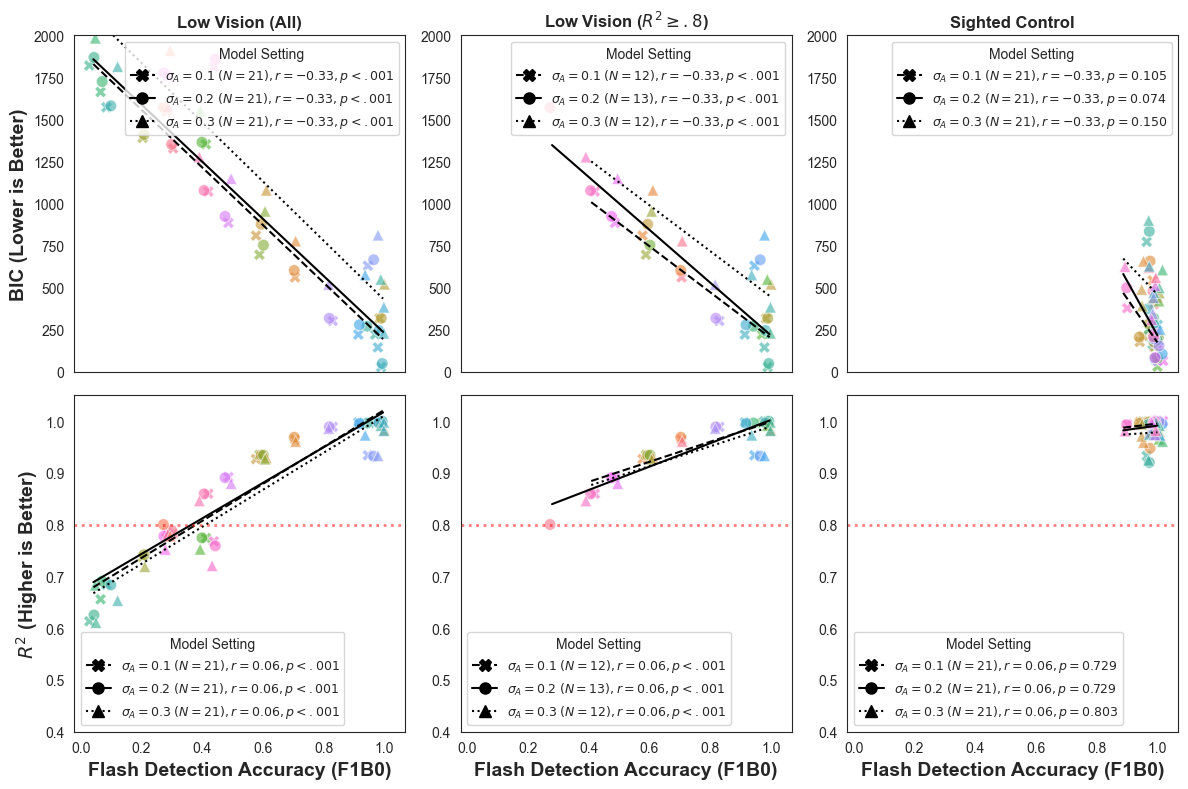

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

def preprocess_bci(df, label):
    df = df[df['location'] == 'raw'].copy()
    df = df.rename(columns={'subject_id': 'sid'})
    df['sigma_label'] = label
    return df

label_01 = r"$\sigma_A = 0.1$"
label_02 = r"$\sigma_A = 0.2$"
label_03 = r"$\sigma_A = 0.3$"

bci_p1_df = preprocess_bci(pd.read_csv('csv/modeling/outputs/sigma_a_p1/bci_best_models.csv'), label_01)
bci_p2_df = preprocess_bci(pd.read_csv('csv/modeling/outputs/sigma_a_p2/bci_best_models.csv'), label_02)
bci_p3_df = preprocess_bci(pd.read_csv('csv/modeling/outputs/sigma_a_p3/bci_best_models.csv'), label_03)

styles = {label_01: '--', label_02: '-', label_03: ':'}
markers = {label_01: 'X', label_02: 'o', label_03: '^'}

bci_combined = pd.concat([bci_p1_df, bci_p2_df, bci_p3_df], ignore_index=True)

df = pd.read_csv('csv/all_participants.csv')
f1b0 = df[(df['n_flash']==1) & (df['n_beep']==0)]
flash_acc = f1b0.groupby(['sid', 'group'])['accuracy'].mean().reset_index()

final_df = bci_combined.merge(flash_acc, on='sid', how='left')
final_df['acc_plotting'] = final_df['accuracy'] + np.random.normal(0, 0.01, len(final_df))
final_df['group_plot'] = final_df['group_x']

final_df.loc[final_df['group_plot'] == 'Low Vision', 'group_plot'] = 'Low Vision (All)'
final_df.loc[final_df['group_plot'] == 'Control', 'group_plot'] = 'Sighted Control'

lv_inc = final_df[(final_df['group_plot'] == 'Low Vision (All)') & (final_df['r2'] >= 0.8)].copy()
lv_inc['group_plot'] = 'Low Vision (to include)'

plot_df = pd.concat([final_df, lv_inc], ignore_index=True)

col_order = ['Low Vision (All)', 'Low Vision (to include)', 'Sighted Control']
row_metrics = ['bic', 'r2']
row_ylabels = ['BIC (Lower is Better)', '$R^2$ (Higher is Better)']

sns.set_style("white")

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True)

for row_idx, metric in enumerate(row_metrics):
    all_p_values = []
    for col_idx, col_name in enumerate(col_order):
        ax = axes[row_idx][col_idx]
        subset = plot_df[plot_df['group_plot'] == col_name]

        handles = []        
        for label in [label_01, label_02, label_03]:
            sigma_data = subset[subset['sigma_label'] == label]
            # Pearson R correlation
            r_val, p_val = pearsonr(sigma_data['accuracy'], sigma_data[metric])
            all_p_values.append(p_val)

    _, p_corrected, _, _ = multipletests(all_p_values, method='fdr_bh')

    p_counter = 0
    for col_idx, col_name in enumerate(col_order):
        ax = axes[row_idx][col_idx]
        subset = plot_df[plot_df['group_plot'] == col_name]

        handles = []        
        for label in [label_01, label_02, label_03]:
            p_val_corr = p_corrected[p_counter]
            p_counter += 1
            sigma_data = subset[subset['sigma_label'] == label]

            # Custom legend labels
            n_val = sigma_data['sid'].nunique()
            p_str = f"p={p_val_corr:.3f}" if p_val_corr >= 0.001 else "p < .001"
            full_label = rf"{label} $(N={n_val}), r={r_val:.2f}, {p_str}$"

            handles.append(mlines.Line2D([], [], color='black', 
                                            marker=markers[label], 
                                            linestyle=styles[label], 
                                            markersize=8, 
                                            label=full_label))
            
            sns.scatterplot(
                data=sigma_data, x='acc_plotting', y=metric, hue='sid', 
                marker=markers[label], s=70, ax=ax, palette='husl', legend=False, alpha=0.6
            )
            
            sns.regplot(
                data=sigma_data, x='accuracy', y=metric, scatter=False, ci=None,
                ax=ax, color='black', label=f"{label} (N={n_val})",
                line_kws={'linestyle': styles[label], 'linewidth': 1.5},
            )

        loc = 'upper right' if row_idx==0 else 'lower left'
        ax.legend(handles=handles, title="Model Setting", fontsize=9, 
                  frameon=True, loc=loc, handlelength=2)


        # Formatting
        if col_idx == 0:
            ax.set_ylabel(row_ylabels[row_idx], fontweight='bold', fontsize=14)
        else:
            ax.set_ylabel("")

        if row_idx == 0:
            title = r"Low Vision ($R^2 \geq .8$)" if "include" in col_name else col_name
            ax.set_title(title, fontweight='bold')
            ax.set_ylim(0, 2000)
        else:
            ax.set_title('')
            ax.set_xlabel('Flash Detection Accuracy (F1B0)', fontweight='bold', fontsize=14)
            if metric == 'r2':
                ax.axhline(0.8, color='red', linestyle=':', lw=2, alpha=0.5)
                ax.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.show()
